In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dotenv import load_dotenv
import psycopg2
import os
from sqlalchemy import create_engine
import phik
from phik.report import plot_correlation_matrix
import warnings
from sklearn.ensemble import RandomForestClassifier

load_dotenv()

HOST = os.getenv("HOST")
DATABASE = os.getenv("DATABASE")
USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
PORT = os.getenv("PORT")

# Bỏ qua cảnh báo của pandas khi dùng psycopg2 trực tiếp với read_sql
warnings.filterwarnings('ignore', category=UserWarning)

try:
    # 1. Kết nối và lấy dữ liệu
    conn = psycopg2.connect(
        host=HOST,
        database=DATABASE,
        user=USER,
        password=PASSWORD,
        port=PORT  # mặc định là 5432
    )
    
    print("Kết nối database thành công!")

    query = """SELECT * FROM "stroke_data";"""
    df = pd.read_sql(query, con=conn)
    print(f"Đã lấy dữ liệu thành công! Kích thước dữ liệu: {df.shape}")

except Exception as e:
    print("Lỗi khi kết nối hoặc lấy dữ liệu:", e)
    df = None # Gán None nếu lỗi để tránh lỗi ở phần sau

finally:
    # Đảm bảo đóng kết nối sau khi lấy xong data
    if 'conn' in locals() and conn:
        conn.close()
        print("Đã đóng kết nối database an toàn.\n")



Kết nối database thành công!
Đã lấy dữ liệu thành công! Kích thước dữ liệu: (35104, 12)
Đã đóng kết nối database an toàn.



Đang huấn luyện mô hình Random Forest để trích xuất độ quan trọng...

--- MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG VỚI ĐỘT QUỴ ---
age                 : 0.3864 (38.64%)
avg_glucose_level   : 0.1964 (19.64%)
bmi                 : 0.1747 (17.47%)
work_type           : 0.0548 (5.48%)
ever_married        : 0.0474 (4.74%)
smoking_status      : 0.0372 (3.72%)
hypertension        : 0.0330 (3.30%)
heart_disease       : 0.0287 (2.87%)
Residence_type      : 0.0210 (2.10%)
gender              : 0.0204 (2.04%)


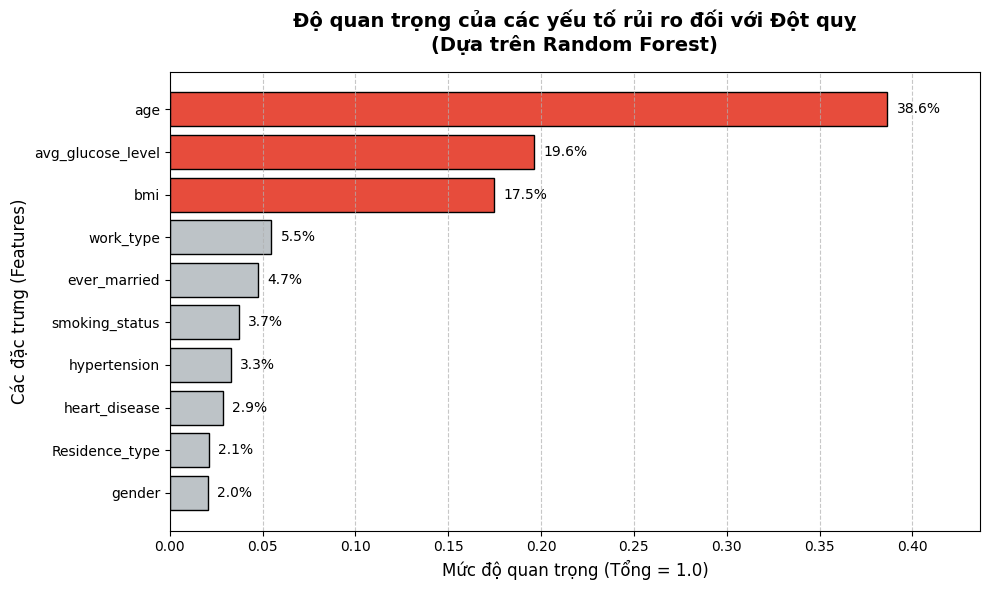

In [2]:
df_encoded = df.copy()

# Xóa cột 'id' vì id không mang giá trị dự đoán
if 'id' in df_encoded.columns:
    df_encoded.drop('id', axis=1, inplace=True)

# Xử lý dữ liệu bị thiếu (Missing Values)
# Cột 'bmi' thường có giá trị NaN, thuật toán cây không nhận giá trị rỗng nên cần điền vào
if df_encoded['bmi'].isnull().sum() > 0:
    df_encoded['bmi'] = df_encoded['bmi'].fillna(df_encoded['bmi'].median())

# Mã hóa các cột dạng text sang số (Label Encoding)
cat_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in cat_columns:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 3. HUẤN LUYỆN MÔ HÌNH RANDOM FOREST
# Tách biến độc lập (X) và biến mục tiêu (y)
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

print("Đang huấn luyện mô hình Random Forest để trích xuất độ quan trọng...")
# Dùng class_weight='balanced' để mô hình chú trọng hơn vào nhóm thiểu số (stroke = 1)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X, y)

# 4. TRÍCH XUẤT VÀ TRỰC QUAN HÓA FEATURE IMPORTANCE
importances = rf_model.feature_importances_

# Tạo DataFrame để dễ thao tác và sắp xếp
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) # Sắp xếp tăng dần để vẽ biểu đồ ngang từ dưới lên

# In ra màn hình console dạng số liệu chi tiết
print("\n--- MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG VỚI ĐỘT QUỴ ---")
for index, row in feature_importance_df.sort_values(by='Importance', ascending=False).iterrows():
    print(f"{row['Feature']:<20}: {row['Importance']:.4f} ({(row['Importance']*100):.2f}%)")

# 5. VẼ BIỂU ĐỒ THANH NGANG (BAR CHART)
fig, ax = plt.subplots(figsize=(10, 6))

# Đổi màu nổi bật (đỏ) cho 3 biến quan trọng nhất, các biến còn lại màu xám
colors = ['#BDC3C7' if i < (len(feature_importance_df)-3) else '#E74C3C' for i in range(len(feature_importance_df))]

bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors, edgecolor='black')

# Định dạng biểu đồ
ax.set_title('Độ quan trọng của các yếu tố rủi ro đối với Đột quỵ\n(Dựa trên Random Forest)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mức độ quan trọng (Tổng = 1.0)', fontsize=12)
ax.set_ylabel('Các đặc trưng (Features)', fontsize=12)

# Thêm lưới dọc mờ để dễ dóng thước
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Ghi chú phần trăm (%) trực tiếp lên từng thanh bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
            f"{(width*100):.1f}%", 
            va='center', fontsize=10)

# Mở rộng giới hạn trục X một chút để số phần trăm không bị cắt mất
ax.set_xlim(0, max(feature_importance_df['Importance']) + 0.05)

plt.tight_layout()
plt.show()